<a href="https://colab.research.google.com/github/KeshavaOfficial/keshav/blob/Projects/XGBM_%26_LGBM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install xgboost

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


In [16]:
d1 = pd.read_csv('/content/Titanic_test.csv')
d2 = pd.read_csv('/content/Titanic_train.csv')

In [17]:
df = pd.concat([d1,d2])

In [18]:
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,NaN
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,NaN
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,NaN
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,NaN
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0.0
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1.0
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0.0
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1.0


In [19]:
type(df)

pandas.core.frame.DataFrame

In [20]:
df.to_csv('Titanic.csv')

In [21]:
df_titanic = pd.read_csv('Titanic.csv')

In [22]:
df_titanic.head()

,Unnamed: 0,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,NaN
1,1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,NaN
2,2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,NaN
3,3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,NaN
4,4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,NaN


In [23]:
df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,263
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,1014


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
 11  Survived     891 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 132.9+ KB


In [25]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,891.000000
mean,655.000000,2.294882,29.881138,0.498854,0.385027,33.295479,0.383838
std,378.020061,0.837836,14.413493,1.041658,0.865560,51.758668,0.486592
min,1.000000,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000
25%,328.000000,2.000000,21.000000,0.000000,0.000000,7.895800,0.000000
50%,655.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,982.000000,3.000000,39.000000,1.000000,0.000000,31.275000,1.000000
max,1309.000000,3.000000,80.000000,8.000000,9.000000,512.329200,1.000000


<Axes: ylabel='Count'>

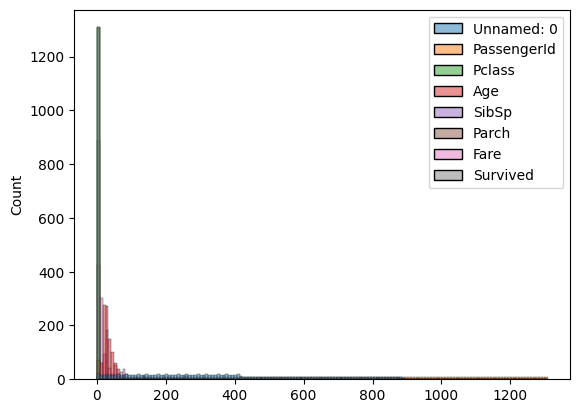

In [27]:
sns.histplot(df_titanic)


<Axes: xlabel='Survived', ylabel='Count'>

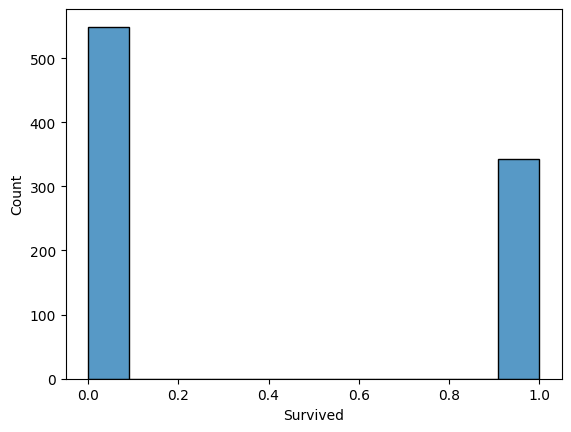

In [28]:
sns.histplot(df_titanic['Survived'])

<Axes: >

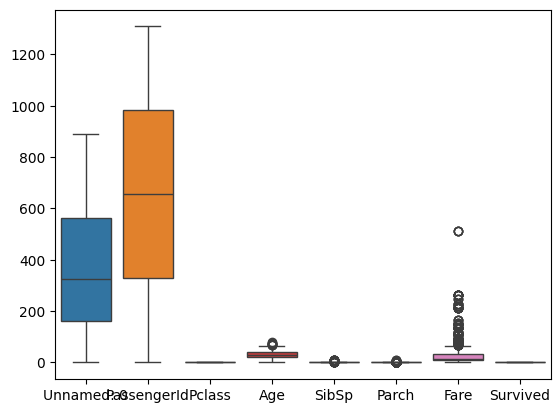

In [30]:
sns.boxplot(df_titanic)

<Axes: xlabel='Sex', ylabel='Survived'>

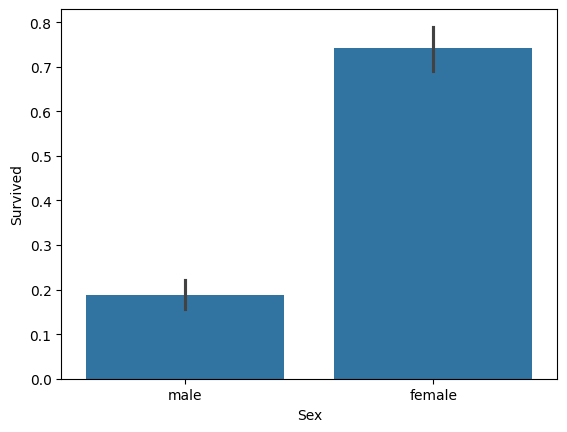

In [32]:
sns.barplot(x = df_titanic['Sex'], y = df_titanic['Survived'])

<Axes: xlabel='Sex', ylabel='Pclass'>

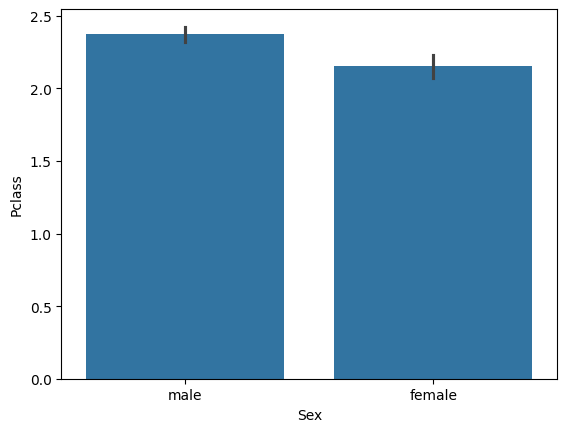

In [39]:
sns.barplot(x = df_titanic['Sex'], y = df_titanic['Pclass'])

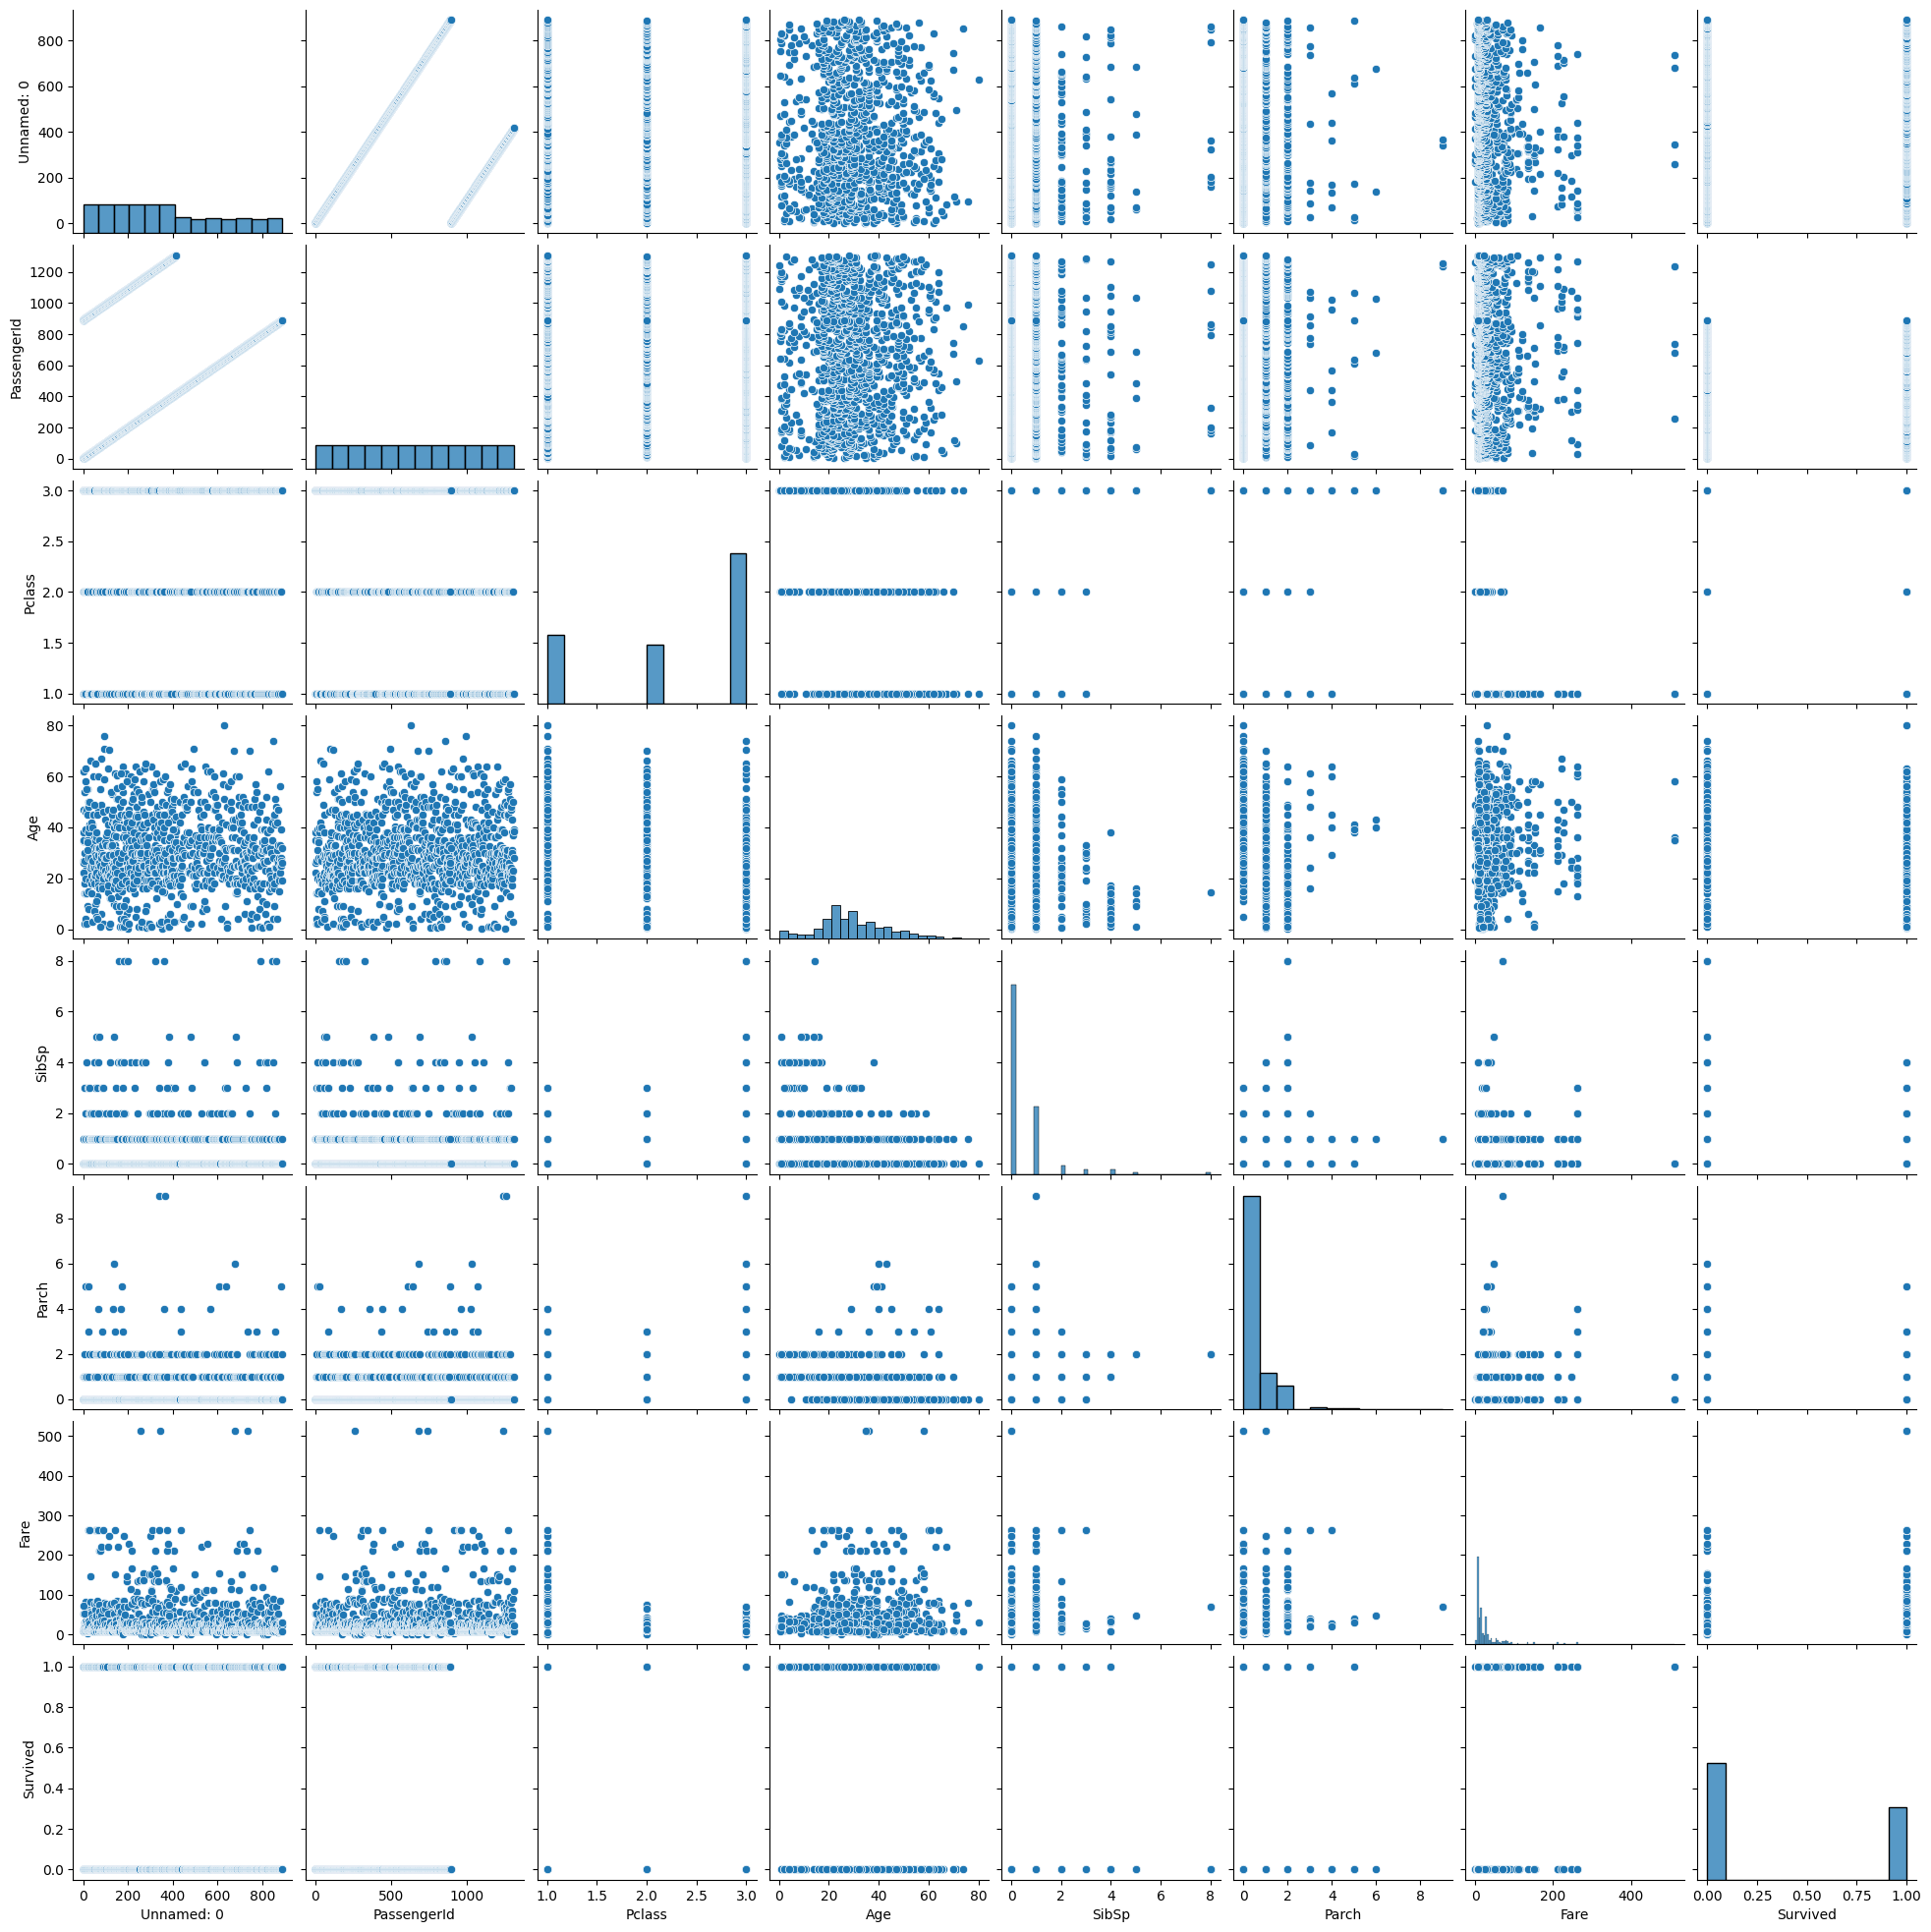

In [40]:
sns.pairplot(df_titanic)

#2.Data Preprocessing


In [45]:
df_titanic.head()

,Unnamed: 0,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,NaN
1,1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,NaN
2,2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,NaN
3,3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,NaN
4,4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,NaN


In [47]:
df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Survived'],
      dtype='object')

In [48]:
x = df_titanic.iloc[:,:-1]
y = df_titanic.iloc[:,-1]

In [50]:
x.head()

,Unnamed: 0,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [51]:
y.head()

,Survived
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


#dropping unnecessary features

In [52]:
x.drop(columns= ['PassengerId','Name','Ticket','Cabin'],inplace = True)

In [53]:
x.head()

,Unnamed: 0,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.5,0,0,7.8292,Q
1,1,3,female,47.0,1,0,7.0000,S
2,2,2,male,62.0,0,0,9.6875,Q
3,3,3,male,27.0,0,0,8.6625,S
4,4,3,female,22.0,1,1,12.2875,S


In [60]:
x.columns

Index(['Pclass', 'Sex', 'Age', 'Embarked'], dtype='object')

In [59]:
x.drop(columns = ['Fare'],inplace = True)

#Categorical to Numerical Conversion

In [65]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
x['Sex'] = le.fit_transform(x['Sex'])
x['Embarked'] = le.fit_transform(x['Embarked'])
x['Pclass']= le.fit_transform(x['Pclass'])



In [66]:
x.head()

,Pclass,Sex,Age,Embarked
0,2,1,34.5,1
1,2,0,47.0,2
2,1,1,62.0,1
3,2,1,27.0,2
4,2,0,22.0,2


In [68]:
y.head()

,Survived
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


#we get error becoz y expected values is 0 or 1 but by using simple imputer we get mean of the survived column

In [71]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy= 'mean')
y['Survived'] = si.fit_transform(y['Survived'])

KeyError: 'Survived'

#in order get rid of that error we do rounding

In [79]:
y.fillna(y.mean(), inplace=True)
y = y.round().astype(int)



In [80]:
y.head()

,Survived
0,0
1,0
2,0
3,0
4,0


#we are Training the data

In [81]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 0)

#Implementing the model on the training data

In [211]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [212]:
y_pred = xgb.predict(x_test)

#finding accuracy

In [213]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
confusion_matrix(y_test,y_pred)
accuracy_score(y_test,y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       191
           1       0.63      0.54      0.58        71

    accuracy                           0.79       262
   macro avg       0.73      0.71      0.72       262
weighted avg       0.78      0.79      0.78       262



#now we do hyper para tunning in XG boost classifier

In [214]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimator = 100, max_depth = 2,learning_rate=0.2)
xgb.fit(x_train,y_train)
y_pred = xgb.predict(x_test)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:57:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimator" } are not used.

  warnings.warn(smsg, UserWarning)


In [215]:


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
xgbm = (confusion_matrix(y_test,y_pred),accuracy_score(y_test,y_pred),print(classification_report(y_test,y_pred)))

              precision    recall  f1-score   support

           0       0.82      0.92      0.86       191
           1       0.67      0.45      0.54        71

    accuracy                           0.79       262
   macro avg       0.74      0.68      0.70       262
weighted avg       0.78      0.79      0.78       262



In [205]:
accuracy_score(y_test,y_pred)

0.7938931297709924

In [180]:
!pip install lightgbm

In [216]:

import lightgbm as lgb
lgb_model = lgb.LGBMClassifier(n_estimators=10, max_depth=2, learning_rate=0.2)
lgb_model.fit(x_train, y_train)
y_pred = lgb_model.predict(x_test)

[LightGBM] [Info] Number of positive: 271, number of negative: 776
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81
[LightGBM] [Info] Number of data points in the train set: 1047, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.258835 -> initscore=-1.052034
[LightGBM] [Info] Start training from score -1.052034
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [217]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
lgbm = (confusion_matrix(y_test,y_pred),accuracy_score(y_test,y_pred),print(classification_report(y_test,y_pred)))

              precision    recall  f1-score   support

           0       0.82      0.91      0.87       191
           1       0.67      0.48      0.56        71

    accuracy                           0.79       262
   macro avg       0.75      0.69      0.71       262
weighted avg       0.78      0.79      0.78       262



In [218]:
# Create a DataFrame for comparison
metrics_df = pd.DataFrame([lgbm, xgbm], index=["LightGBM", "XGBoost"])
print(metrics_df)
accuracy_score(y_test,y_pred)

                              0         1     2
LightGBM  [[174, 17], [37, 34]]  0.793893  None
XGBoost   [[175, 16], [39, 32]]  0.790076  None


0.7938931297709924

In [199]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgb,x,y,cv = 10)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:51:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimator" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:51:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimator" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:51:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimator" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:51:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimator" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:51:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimator" } are not used.

  war

In [200]:

print("Cross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross-validation scores: [0.70992366 0.70229008 0.70229008 0.80916031 0.80152672 0.82442748
 0.82442748 0.81679389 0.86259542 0.85384615]
Mean Accuracy: 0.790728126834997


In [219]:
# Create a DataFrame for comparison
metrics_df = pd.DataFrame([lgbm, xgbm], index=["LightGBM", "XGBoost"])
print(metrics_df)


                              0         1     2
LightGBM  [[174, 17], [37, 34]]  0.793893  None
XGBoost   [[175, 16], [39, 32]]  0.790076  None


<Figure size 1000x500 with 0 Axes>

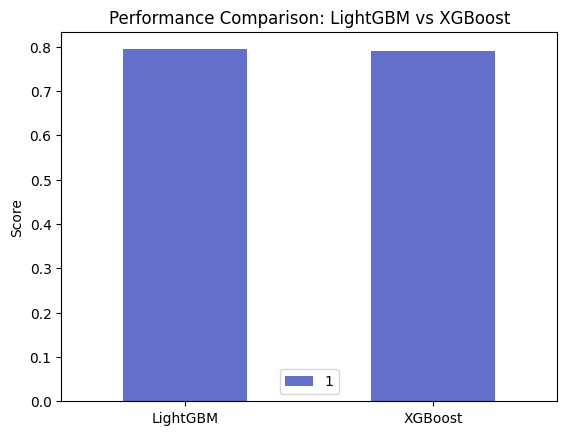

In [220]:
# Plot comparison
plt.figure(figsize=(10, 5))
metrics_df.plot(kind='bar', colormap='coolwarm', alpha=0.8)
plt.title("Performance Comparison: LightGBM vs XGBoost")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.show()
